# 04 — Dunkelflaute: ERA5 modelled droughts vs SMARD, and the blocking link

**Question.** Do capacity-weighted renewable droughts ("Dunkelflaute") in
ERA5 line up with what SMARD measured, and do they coincide with detected
blocking?

**Key results.**

- SMARD capacity weights (Dec 2024): 86.4 GW solar, 63.2 GW onshore wind, 7.4 GW North-Sea and 1.8 GW Baltic offshore — onshore+solar dominate, so an offshore-only proxy is unrepresentative.
- The daily capacity-weighted national CF index tracks SMARD with correlation 0.96–0.98 and bias −0.004…+0.015 across the five winters.
- At daily CF < 0.10 for ≥ 48 h: 31 SMARD events vs 30 ERA5 events — 28 hits, 3 misses, 2 false alarms.
- P(drought day | European-sector blocked) = 0.47 vs P(drought) = 0.26 overall — an association consistent with the Z500-ridge composite, with no significance claim (small autocorrelated sample).

## Method

- **National renewable CF**: capacity-weighted mix of onshore wind, offshore
  wind (North Sea + Baltic basins) and solar. SMARD installed capacity
  (~60 GW onshore, ~9 GW offshore, ~80+ GW solar) supplies the weights —
  an offshore-only proxy would describe a small slice of the fleet.
- **Wind** uses the notebook-02 transfer (`field` aggregation); **solar**
  uses the transparent proxy CF ≈ SSRD/1000 W m⁻² (no PV-system model).
- **Definition** follows the literature habit of smoothing the diurnal cycle:
  drought events are runs of *daily-mean* CF below a threshold, cf. Kittel &
  Schill (2024) and Li et al. (2021). Hourly thresholds would mostly count
  the nights.
- **The SMARD index** is built identically: capacity-weighted over all zones
  and technologies, then daily means.
- **Events**: consecutive days below a CF threshold for at least a minimum
  duration. Verified as hits / misses / false alarms by date overlap.
- Grouped by winter (Dec–Feb), not calendar year.

In [1]:
# Purpose: project root, config, shared plotting style.
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from eurogrid import plotting

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config/settings.yaml").exists()
)
os.chdir(ROOT)
cfg = yaml.safe_load(open(ROOT / "config/settings.yaml"))
plotting.apply_style()

In [2]:
# Purpose: installed-capacity weights and both national CF indices.
from datetime import datetime

from eurogrid.data.era5 import load_era5
from eurogrid.data.smard import SmardClient
from eurogrid.diagnostics import dunkelflaute as dk

client = SmardClient(cache_dir=cfg["smard"]["cache_dir"], pause_s=0)
cap_all = client.load_installed_capacity(datetime(2024, 12, 1), datetime(2025, 1, 1))
W = dk.capacity_weights(cap_all)
print("weights (MW):", {k: round(v) for k, v in W.items()})

weights (MW): {'solar': 86408, 'wind_offshore_north_sea': 7387, 'wind_onshore': 63192, 'wind_offshore_baltic': 1828}


In [3]:
# Purpose: ERA5 national renewable CF for each of the five winters.
MONTHS = [(12, 0), (1, 1), (2, 1)]  # Dec of year y, Jan and Feb of y+1
era5_cf = {}
for w in cfg["blocking"]["benchmark_windows"]:
    y = int(w["label"][:4])
    frames = []
    for m, off in MONTHS:
        s, e = (
            datetime(y + off, m, 1),
            (datetime(y + off + (m == 12), 1, 1) if m == 12 else datetime(y + off, m + 1, 1)),
        )
        ds = load_era5(
            s,
            e,
            **cfg["domain"],
            cache_dir=cfg["era5"]["cache_dir"],
            z500_stride_hours=cfg["era5"]["z500_stride_hours"],
        )
        frames.append(dk.era5_renewable_cf(ds, W))
    era5_cf[w["label"]] = pl.concat(frames).unique("time").sort("time")
    print(w["label"], era5_cf[w["label"]].height)

2020-21 2160


2021-22 2160


2022-23 2160


2023-24 2184


2024-25 2160


In [4]:
# Purpose: the SMARD national index for the same five winters.
smard_cf = {}
for w in cfg["blocking"]["benchmark_windows"]:
    y = int(w["label"][:4])
    s, e = datetime(y, 12, 1), datetime(y + 1, 3, 1)
    gen = client.load_generation(s, e)
    cap = client.load_installed_capacity(s, e)
    smard_cf[w["label"]] = dk.smard_renewable_cf(gen, cap)
    print(w["label"], smard_cf[w["label"]].height)

2020-21 2160


2021-22 2160


2022-23 2160


2023-24 2184


2024-25 2160


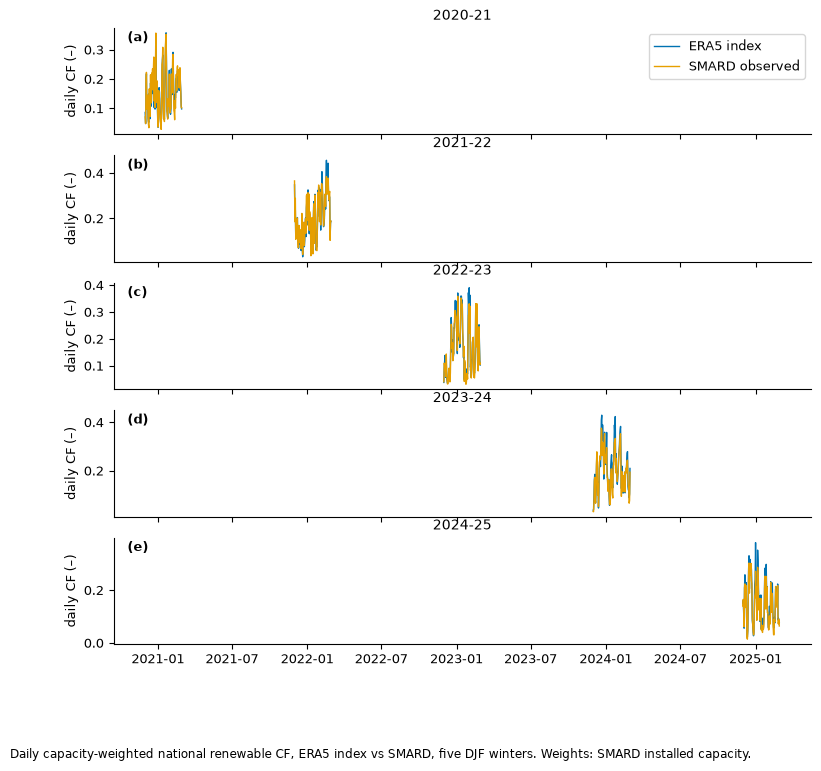

In [5]:
# Purpose: daily-mean national CF, ERA5 vs SMARD, per winter.
daily_e = {k: dk.daily_mean(v) for k, v in era5_cf.items()}
daily_s = {k: dk.daily_mean(v) for k, v in smard_cf.items()}
fig, axes = plt.subplots(5, 1, figsize=(9, 8), sharex=True)
for ax, label in zip(axes, daily_e, strict=True):
    j = daily_e[label].join(daily_s[label], on="time", suffix="_obs")
    ax.plot(j["time"].to_numpy(), j["cf"].to_numpy(), lw=1.0, label="ERA5 index")
    ax.plot(j["time"].to_numpy(), j["cf_obs"].to_numpy(), lw=1.0, label="SMARD observed")
    ax.set_ylabel("daily CF (–)")
    ax.set_title(label)
axes[0].legend()
plotting.label_panels(axes)
plotting.caption(
    fig,
    "Daily capacity-weighted national renewable CF, ERA5 index vs SMARD, "
    "five DJF winters. Weights: SMARD installed capacity.",
)
plt.show()

In [6]:
# Purpose: daily-CF agreement per winter (corr, bias, RMSE).
rows = []
for label in daily_e:
    j = (
        daily_e[label]
        .join(daily_s[label], on="time", suffix="_obs")
        .filter(pl.col("cf").is_finite() & pl.col("cf_obs").is_finite())
    )
    rows.append(
        {
            "winter": label,
            "n_days": j.height,
            "corr": j.select(pl.corr("cf", "cf_obs")).item(),
            "bias": float((j["cf"] - j["cf_obs"]).mean()),
            "rmse": float(((j["cf"] - j["cf_obs"]) ** 2).mean() ** 0.5),
        }
    )
display(pl.DataFrame(rows).with_columns(pl.col("corr", "bias", "rmse").round(3)))

winter,n_days,corr,bias,rmse
str,i64,f64,f64,f64
"""2020-21""",90,0.966,-0.004,0.021
"""2021-22""",90,0.975,-0.004,0.023
"""2022-23""",90,0.978,0.006,0.022
"""2023-24""",91,0.963,0.013,0.029
"""2024-25""",90,0.974,0.015,0.026


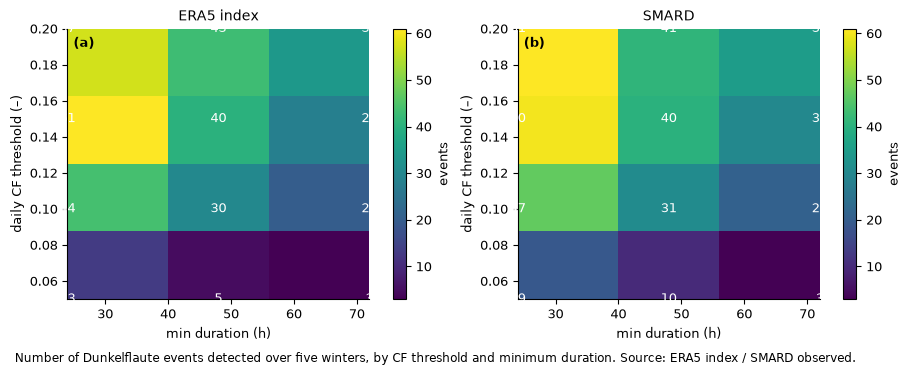

In [7]:
# Purpose: threshold x duration sweep as one heat map each for ERA5 and SMARD.
ths = cfg["dunkelflaute"]["capacity_factor_thresholds"]
durs = cfg["dunkelflaute"]["min_duration_hours"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
for ax, (title, daily) in zip(axes, [("ERA5 index", daily_e), ("SMARD", daily_s)], strict=True):
    all_cf = pl.concat(daily.values())
    M = np.array([[dk.detect_events(all_cf, t, d).height for d in durs] for t in ths])
    im = ax.imshow(
        M,
        cmap=plotting.SEQUENTIAL_CMAP,
        origin="lower",
        extent=[min(durs), max(durs), min(ths), max(ths)],
        aspect="auto",
    )
    for i, t in enumerate(ths):
        for j, d in enumerate(durs):
            ax.text(d, t, M[i, j], ha="center", va="center", color="w", fontsize=9)
    ax.set_xlabel("min duration (h)")
    ax.set_ylabel("daily CF threshold (–)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="events")
plotting.label_panels(axes)
plotting.caption(
    fig,
    "Number of Dunkelflaute events detected over five winters, by CF threshold "
    "and minimum duration. Source: ERA5 index / SMARD observed.",
)
plt.show()

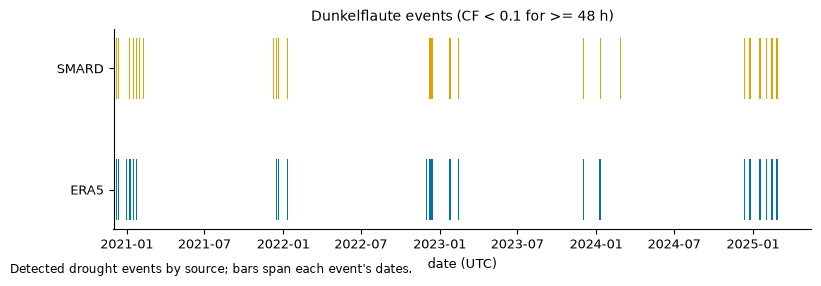

observed_events,modelled_events,hits,misses,false_alarms
i64,i64,i64,i64,i64
31,30,28,3,2


In [8]:
# Purpose: event timelines + hits/misses/false alarms at a headline definition.
THRESH, MIND = 0.10, 48
ev_e = dk.detect_events(pl.concat(daily_e.values()), THRESH, MIND)
ev_s = dk.detect_events(pl.concat(daily_s.values()), THRESH, MIND)
fig, ax = plt.subplots(figsize=(9, 2.6))
for i, (ev, _name, c) in enumerate(
    [(ev_e, "ERA5 index", plotting.PALETTE[0]), (ev_s, "SMARD", plotting.PALETTE[1])]
):
    for row in ev.iter_rows(named=True):
        ax.barh(
            i, (row["end"] - row["start"]).total_seconds() / 86400, left=row["start"], height=0.5, color=c
        )
ax.set_yticks([0, 1], ["ERA5", "SMARD"])
ax.set_xlabel("date (UTC)")
ax.set_title(f"Dunkelflaute events (CF < {THRESH} for >= {MIND} h)")
plotting.caption(fig, "Detected drought events by source; bars span each event's dates.")
plt.show()
ver = dk.event_verification(ev_e, ev_s)
display(pl.DataFrame([ver]))

In [9]:
# Purpose: P(Dunkelflaute | blocked) vs P(Dunkelflaute) using notebook-03 masks.
from eurogrid.data.era5 import load_era5_z500
from eurogrid.diagnostics.blocking import daily_mean_z500, detect_tm1990, persistence_summary

EU_SECTOR = (-30.0, 30.0)  # European longitudes used for the 'blocked day' flag
blocked_days = set()
z500 = {}
bcfg = cfg["blocking"]
dom = bcfg["domain"]
for w in bcfg["benchmark_windows"]:
    z = load_era5_z500(
        datetime.fromisoformat(w["start"]),
        datetime.fromisoformat(w["end"]),
        lat_min=dom["lat_min"],
        lat_max=dom["lat_max"],
        lon_min=dom["lon_min"],
        lon_max=dom["lon_max"],
        cache_dir=cfg["era5"]["cache_dir"],
        z500_stride_hours=cfg["era5"]["z500_stride_hours"],
    )
    z500[w["label"]] = z
    daily = daily_mean_z500(z)
    r = detect_tm1990(
        daily,
        phi0_deg=bcfg["phi0_deg"],
        arm_deg=bcfg["arm_deg"],
        scan_offsets_deg=tuple(bcfg["scan_offsets_deg"]),
        ghgn_threshold_m_per_deg=bcfg["ghgn_threshold_m_per_deg"],
        min_sector_width_deg=bcfg["min_sector_width_deg"],
    )
    p = persistence_summary(
        r["blocking"],
        timestep_hours=24,
        min_persistence_days=bcfg["min_persistence_days"],
        tolerance_deg=bcfg["persistence_lon_tolerance_deg"],
    )
    eu = p["persistent_blocking"].sel(lon=slice(*EU_SECTOR)).any("lon")
    blocked_days |= {t.astype("datetime64[D]").item() for t in eu["time_z500"].values[eu.values]}
out = dk.conditional_drought_probability(pl.concat(daily_e.values()), THRESH, blocked_days)
display(pl.DataFrame([out]).with_columns(pl.col("p_drought", "p_drought_given_blocked").round(3)))

n_days,n_blocked_days,p_drought,p_drought_given_blocked
i64,i64,f64,f64
451,79,0.259,0.468


**Reading it.** `p_drought` is the fraction of winter days with daily
national CF < threshold; `p_drought_given_blocked` the same restricted to
days with a persistent block in the European sector (−30…30°E). A clear
difference would be *evidence of association only* — the sample is ~450
days, autocorrelated, so no significance claim is made without a block
bootstrap.

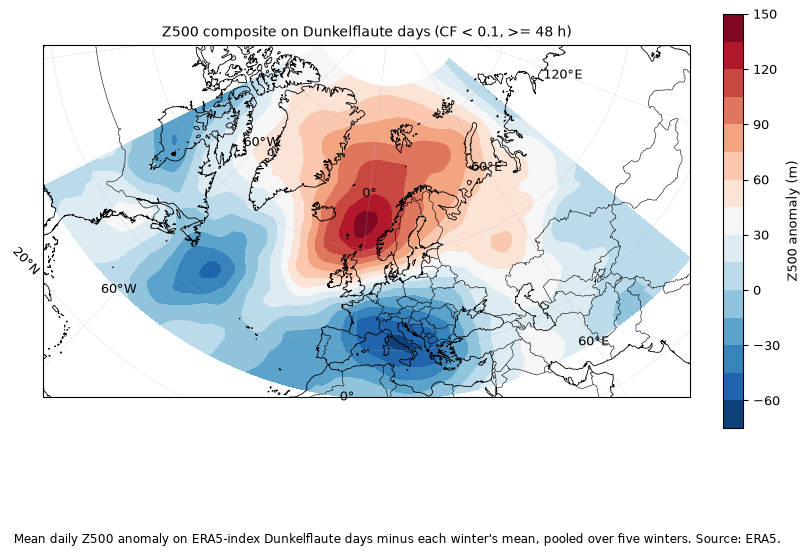

In [10]:
# Purpose: Z500-anomaly composite over Dunkelflaute days (ERA5 index).
import cartopy.crs as ccrs
import xarray as xr

comp = {}
for w in bcfg["benchmark_windows"]:
    z = z500[w["label"]].isel(time_z500=slice(None, None, 4))  # daily 00 UTC
    z = z.assign_coords(time_z500=z["time_z500"].values.astype("datetime64[D]"))
    drought = set(dk.detect_events(daily_e[w["label"]], THRESH, MIND)["start"].dt.date().to_list())
    sel = [np.datetime64(d, "D") in [np.datetime64(d2, "D") for d2 in drought] for d in z["time_z500"].values]
    comp[w["label"]] = z.isel(time_z500=np.asarray(sel)).mean("time_z500") - z.mean("time_z500")
cmap = xr.concat(list(comp.values()), dim="winter").mean("winter")
fig, ax = plotting.map_axes(extent=(-90, 90, 30, 85))
pc = ax.contourf(
    cmap["lon"], cmap["lat"], cmap, levels=14, cmap=plotting.DIVERGING_CMAP, transform=ccrs.PlateCarree()
)
fig.colorbar(pc, ax=ax, shrink=0.7, label="Z500 anomaly (m)")
ax.set_title(f"Z500 composite on Dunkelflaute days (CF < {THRESH}, >= {MIND} h)")
plotting.caption(
    fig,
    "Mean daily Z500 anomaly on ERA5-index Dunkelflaute days minus each winter's "
    "mean, pooled over five winters. Source: ERA5.",
)
plt.show()

## Limitations and next step

- The solar proxy ignores tilt, temperature and fleet placement; the wind
  index uses static fleet boxes — biases against SMARD are reported, not
  tuned away.
- ~450 days and few events: hit/miss counts and the conditional probability
  are descriptive; a block bootstrap is needed before significance claims.
- Blocking ↔ drought is association, not causation.
- **Next:** evaluate the EERIE historical run against this benchmark before
  any future projection.